#Final Project

# 1) Import Libraries

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.pipeline import Pipeline

# 2) Data Import

In [106]:
df = pd.read_csv("/content/loan_data.csv")

# 3) Data Exploration

In [107]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [108]:
df.tail()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1
44999,24.0,male,High School,51609.0,1,RENT,6665.0,DEBTCONSOLIDATION,17.05,0.13,3.0,628,No,1


In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [110]:
df.shape

(45000, 14)

In [111]:
df.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')

In [112]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


Max personal_age :144 ??
ma shaa allah 😂

In [113]:
df.isnull().sum()

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


In [114]:
df.duplicated().sum()

np.int64(0)

In [115]:
cols = [
    "person_gender",
    "person_education",
    "person_home_ownership",
    "loan_intent",
    "previous_loan_defaults_on_file"
]

for column in cols:
    print(f"{column}")
    print(df[column].unique())
    print("_" * 30)

person_gender
['female' 'male']
______________________________
person_education
['Master' 'High School' 'Bachelor' 'Associate' 'Doctorate']
______________________________
person_home_ownership
['RENT' 'OWN' 'MORTGAGE' 'OTHER']
______________________________
loan_intent
['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']
______________________________
previous_loan_defaults_on_file
['No' 'Yes']
______________________________


In [116]:
cols = [
    "person_gender",
    "person_education",
    "person_home_ownership",
    "loan_intent",
    "previous_loan_defaults_on_file"
]

for column in cols:
    print(df[column].value_counts())
    print("_" * 30)

person_gender
male      24841
female    20159
Name: count, dtype: int64
______________________________
person_education
Bachelor       13399
Associate      12028
High School    11972
Master          6980
Doctorate        621
Name: count, dtype: int64
______________________________
person_home_ownership
RENT        23443
MORTGAGE    18489
OWN          2951
OTHER         117
Name: count, dtype: int64
______________________________
loan_intent
EDUCATION            9153
MEDICAL              8548
VENTURE              7819
PERSONAL             7552
DEBTCONSOLIDATION    7145
HOMEIMPROVEMENT      4783
Name: count, dtype: int64
______________________________
previous_loan_defaults_on_file
Yes    22858
No     22142
Name: count, dtype: int64
______________________________


In [117]:
df["loan_status"].value_counts(normalize=True) * 100

,proportion
loan_status,
0,77.777778
1,22.222222


#EDA

In [118]:
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include="object").columns

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'loan_status'],
      dtype='object')

Categorical Columns:
Index(['person_gender', 'person_education', 'person_home_ownership',
       'loan_intent', 'previous_loan_defaults_on_file'],
      dtype='object')


In [119]:
df[numerical_cols].describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


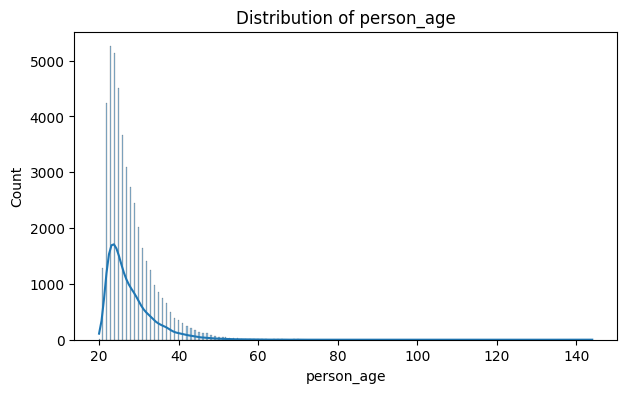

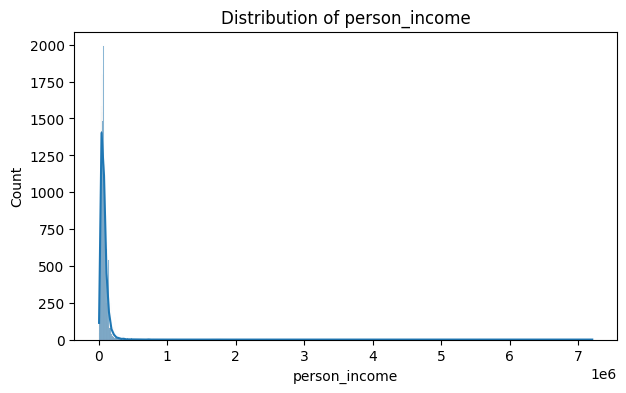

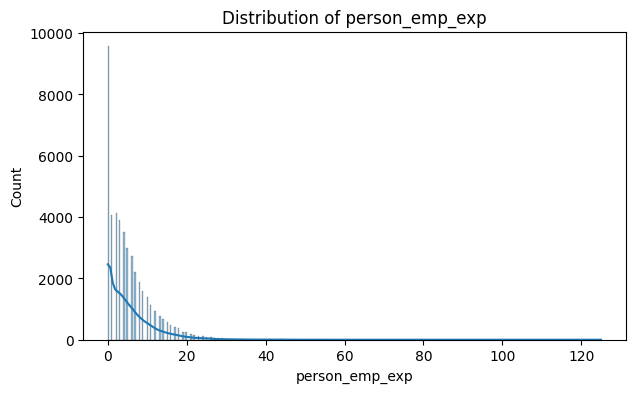

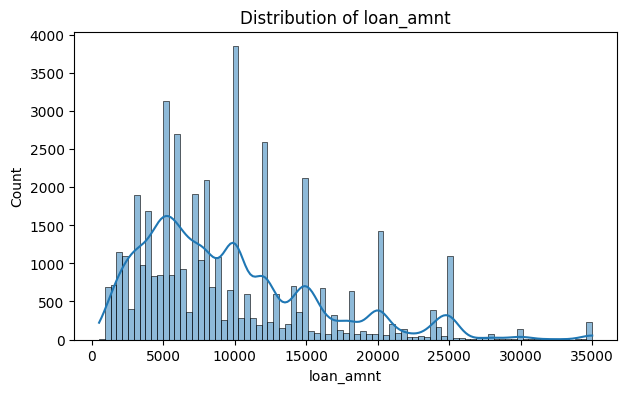

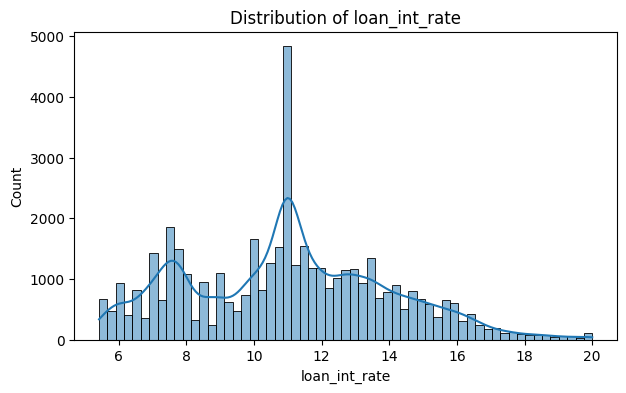

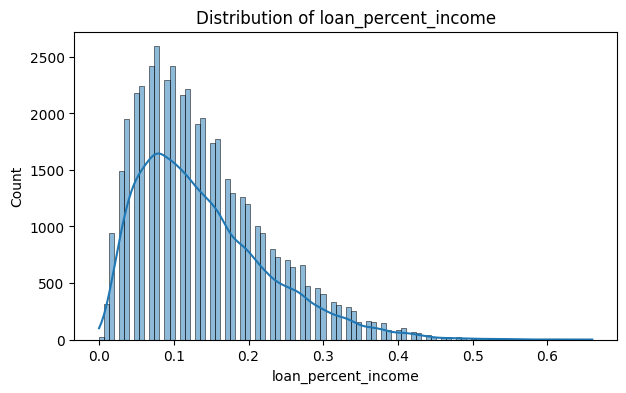

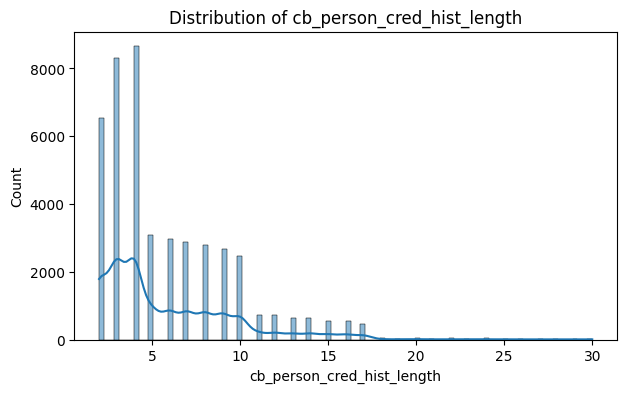

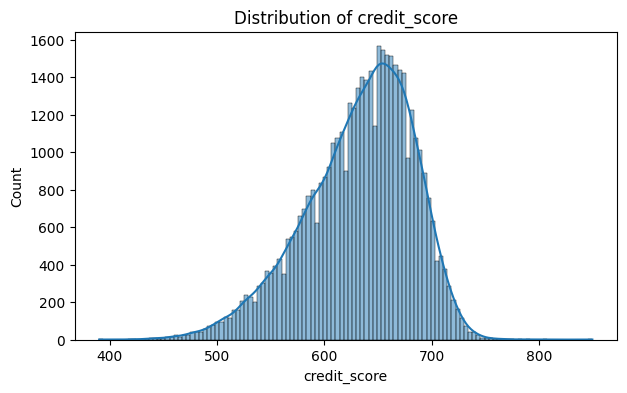

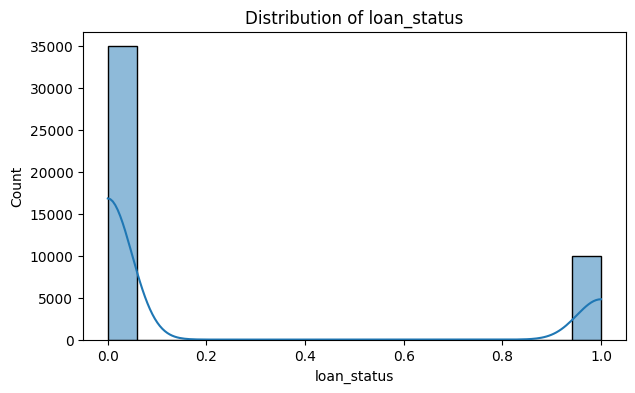

In [120]:
for column in numerical_cols:
    plt.figure(figsize=(7, 4))

    sns.histplot(data=df, x=column, kde=True)

    plt.title(f"Distribution of {column}")
    plt.show()

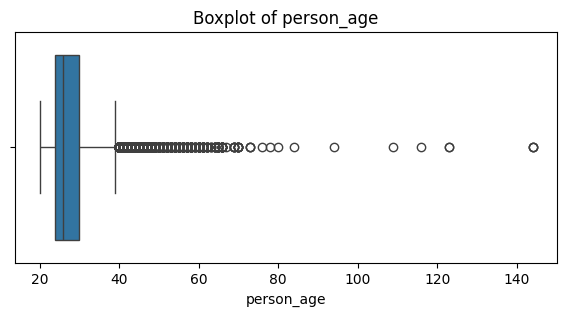

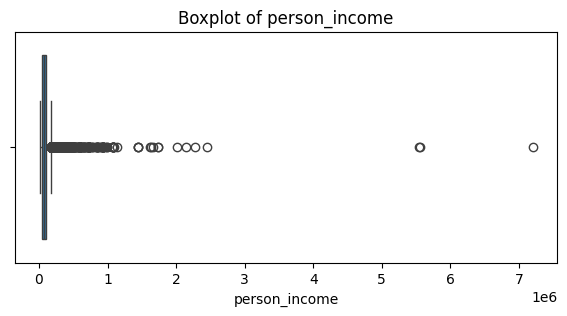

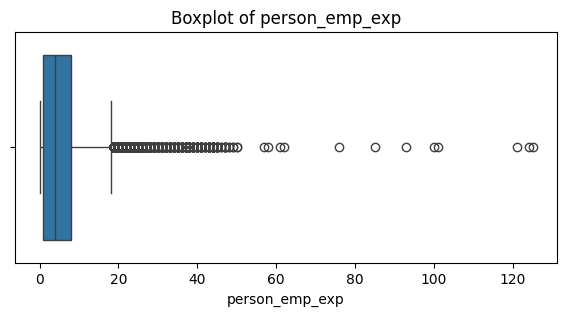

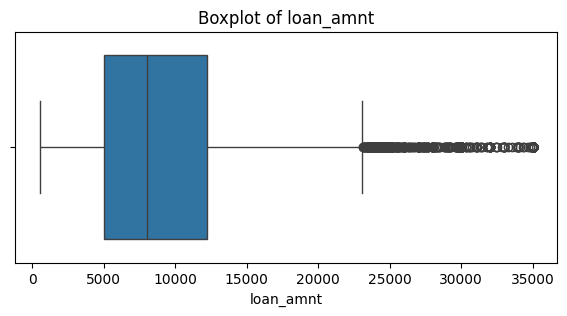

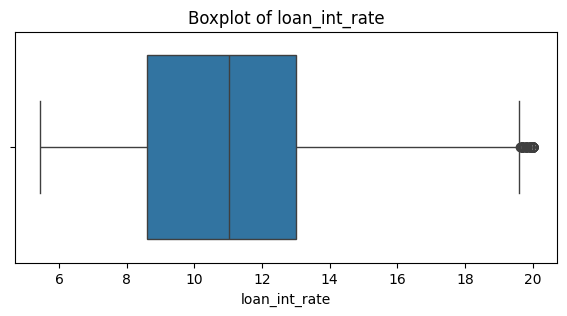

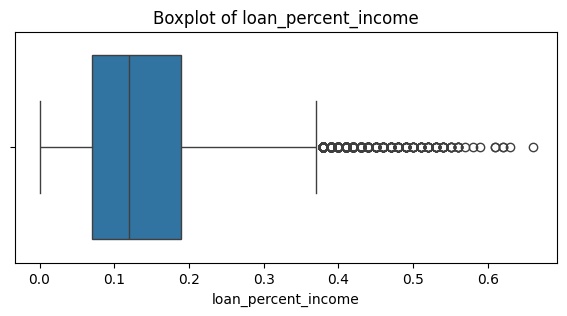

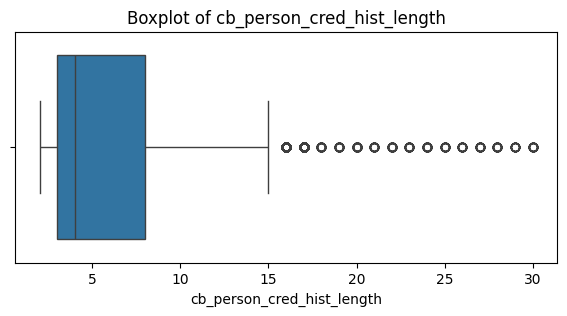

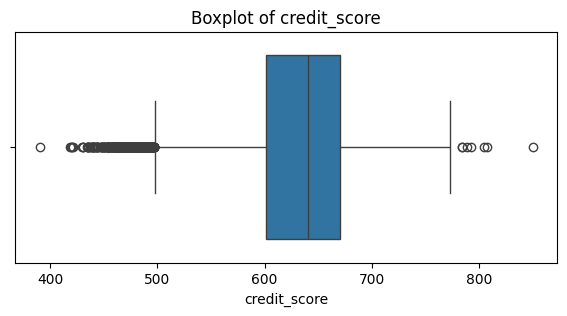

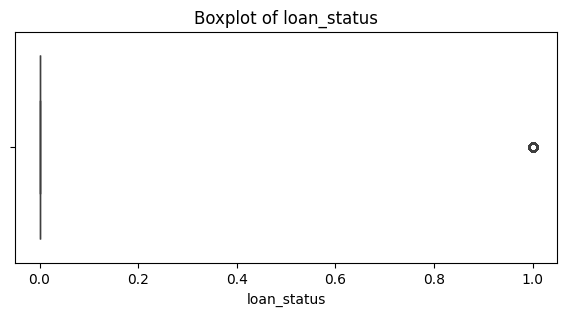

In [121]:
for column in numerical_cols:
    plt.figure(figsize=(7, 3))

    sns.boxplot(x=df[column])

    plt.title(f"Boxplot of {column}")
    plt.show()

In [122]:
for column in categorical_cols:
    print(f"\n{column}")
    print(df[column].value_counts())
    print("_" * 30)


person_gender
person_gender
male      24841
female    20159
Name: count, dtype: int64
______________________________

person_education
person_education
Bachelor       13399
Associate      12028
High School    11972
Master          6980
Doctorate        621
Name: count, dtype: int64
______________________________

person_home_ownership
person_home_ownership
RENT        23443
MORTGAGE    18489
OWN          2951
OTHER         117
Name: count, dtype: int64
______________________________

loan_intent
loan_intent
EDUCATION            9153
MEDICAL              8548
VENTURE              7819
PERSONAL             7552
DEBTCONSOLIDATION    7145
HOMEIMPROVEMENT      4783
Name: count, dtype: int64
______________________________

previous_loan_defaults_on_file
previous_loan_defaults_on_file
Yes    22858
No     22142
Name: count, dtype: int64
______________________________


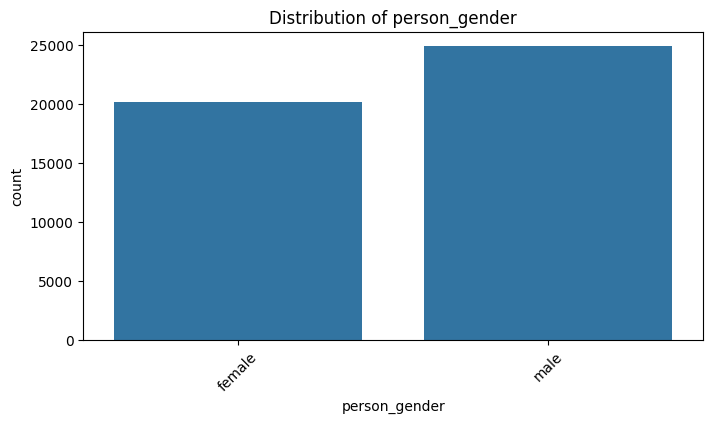

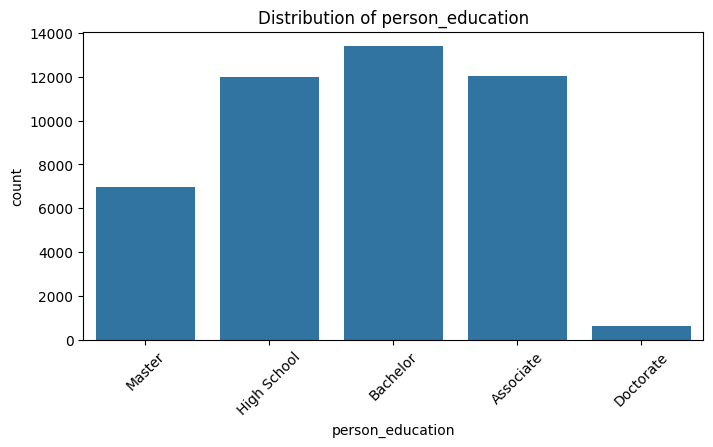

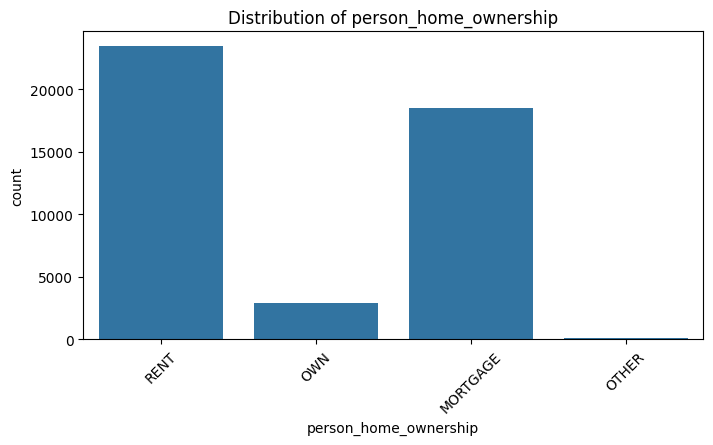

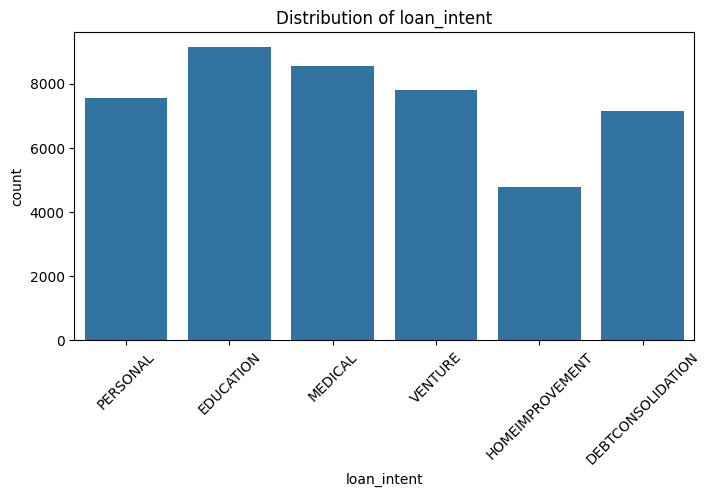

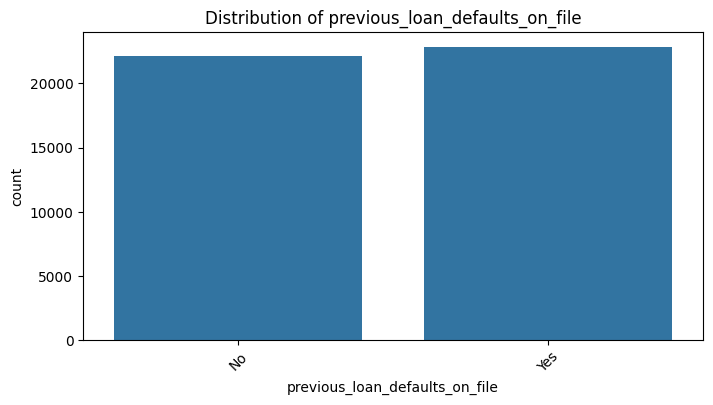

In [123]:
for column in categorical_cols:
    plt.figure(figsize=(8, 4))

    sns.countplot(data=df, x=column)

    plt.title(f"Distribution of {column}")
    plt.xticks(rotation=45)
    plt.show()

In [124]:
df["loan_status"].value_counts()   #target

,count
loan_status,
0,35000
1,10000


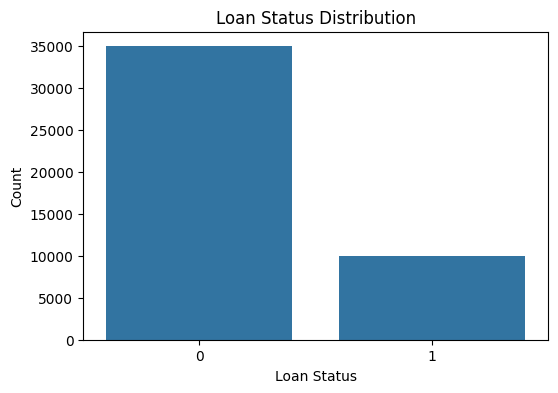

In [125]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="loan_status")

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.show()

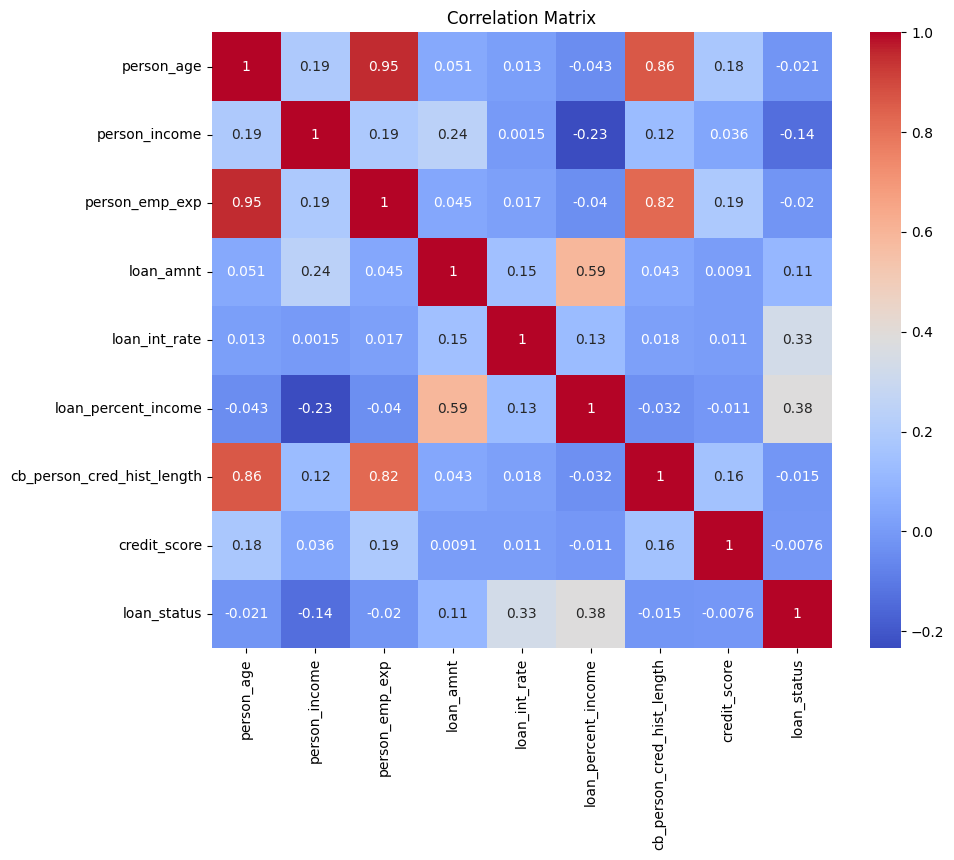

In [126]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [127]:
Q1 = df["person_income"].quantile(0.25)
Q3 = df["person_income"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Bound:", lower)
print("Upper Bound:", upper)

Lower Bound: -25673.875
Upper Bound: 168667.125


In [128]:
outliers = df[
    (df["person_income"] < lower) |
    (df["person_income"] > upper)
]

print("Number of Outliers:", len(outliers))

Number of Outliers: 2218


#Data Processing & Cleaning

In [129]:
df = df.drop(columns=["person_gender"])

In [130]:
df = df[
    (df["person_age"] >= 18) &
    (df["person_age"] <= 90)
]

In [131]:
df = df[
    df["person_emp_exp"] <= df["person_age"] - 18
]


In [132]:
df[[
    "person_age",
    "person_emp_exp",
    "person_income"
]].describe()

,person_age,person_emp_exp,person_income
count,44992.000000,44992.000000,4.499200e+04
mean,27.746955,5.392959,7.990956e+04
std,5.901543,5.917871,6.332239e+04
min,20.000000,0.000000,8.000000e+03
25%,24.000000,1.000000,4.719725e+04
50%,26.000000,4.000000,6.704600e+04
75%,30.000000,8.000000,9.577900e+04
max,84.000000,62.000000,2.448661e+06


In [133]:
df = df[
    (df["person_income"] >= 0) &
    (df["person_income"] <= 1_000_000)
]

In [134]:
df.dropna(subset=['loan_status'], inplace=True)

In [135]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,44971.000000,44971.000000,44971.000000,44971.000000,44971.000000,44971.000000,44971.00000,44971.000000,44971.000000
mean,27.739365,79249.103511,5.385271,9581.929599,11.006642,0.139795,5.86140,632.582331,0.222366
std,5.889774,54684.023604,5.905306,6313.488774,2.979295,0.087182,3.86904,50.400616,0.415840
min,20.000000,8000.000000,0.000000,500.000000,5.420000,0.000000,2.00000,390.000000,0.000000
25%,24.000000,47174.000000,1.000000,5000.000000,8.590000,0.070000,3.00000,601.000000,0.000000
50%,26.000000,67040.000000,4.000000,8000.000000,11.010000,0.120000,4.00000,640.000000,0.000000
75%,30.000000,95698.500000,8.000000,12236.000000,13.000000,0.190000,8.00000,670.000000,0.000000
max,84.000000,994605.000000,62.000000,35000.000000,20.000000,0.660000,30.00000,784.000000,1.000000


## **Data** **splitting**

In [136]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# **Encoding** & **Scaling**

In [137]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# **Modeling**

# **Logistic** **Regression**

In [138]:
logistic_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['person_education', 'person_home_ownership', 'loan_intent',
       'previous_loan_defaults_on_file'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [139]:
logistic_train_acc = logistic_model.score(X_train, y_train)
logistic_test_acc = logistic_model.score(X_test, y_test)

print("Logistic Regression Train Accuracy:", logistic_train_acc)
print("Logistic Regression Test Accuracy:", logistic_test_acc)

Logistic Regression Train Accuracy: 0.8965421392039137
Logistic Regression Test Accuracy: 0.8959421901056143


# **Decision** **Tree**

In [140]:
from sklearn.tree import DecisionTreeClassifier

tree_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'
    ))
])

tree_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['person_education', 'person_home_ownership', 'loan_intent',
       'previous_loan_defaults_on_file'],
      dtype='object'))])),
                ('model',
                 DecisionTreeClassifier(class_weight='balanced',
                                        random_state=42))])

# **Using** **GriadSearch**

In [141]:
param_grid = {
    'model__max_depth': [3, 5, 7, 10, 15],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 5, 10]
}

grid_search = GridSearchCV(
    tree_model,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score'],
      dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         Index(['person_education', 'person_home_ownership', 'loan_intent',
       'previous_loan_defaults_on_file'],
      dtype='object'))])),
                                       ('model',
                                        DecisionTreeClassifier(class_weight='balanced',
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [3, 5, 7, 10, 15],
                         'model__min_samples_leaf': [1, 2, 5, 10],
                         'model__min_samples_split': [2, 5, 10]},
             scoring='f1')

In [142]:
print("Best Parameters:")
print(grid_search.best_params_)

print("Best CV Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2}
Best CV Accuracy:
0.7829413145034367


In [143]:
best_tree = grid_search.best_estimator_
best_tree_train_acc = best_tree.score(X_train, y_train)
best_tree_test_acc = best_tree.score(X_test, y_test)

print(" Decision Tree Train Accuracy:", best_tree_train_acc)
print(" Decision Tree Test Accuracy:", best_tree_test_acc)

 Decision Tree Train Accuracy: 0.9059928841449856
 Decision Tree Test Accuracy: 0.8943857698721512


# **Evaluation**

In [144]:
models = {
    "Decision Tree": best_tree,
    "Logistic Regression": logistic_model
}

for name, model in models.items():

    y_pred = model.predict(X_test)

    print("\n", name)

    print("Accuracy:",
          accuracy_score(y_test, y_pred))

    print("Precision:",
          precision_score(y_test, y_pred))

    print("Recall:",
          recall_score(y_test, y_pred))

    print("F1 Score:",
          f1_score(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


 Decision Tree
Accuracy: 0.8943857698721512
Precision: 0.7122069523039612
Recall: 0.881
F1 Score: 0.7876620473848904

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.90      0.93      6995
           1       0.71      0.88      0.79      2000

    accuracy                           0.89      8995
   macro avg       0.84      0.89      0.86      8995
weighted avg       0.91      0.89      0.90      8995


 Logistic Regression
Accuracy: 0.8959421901056143
Precision: 0.7756476683937824
Recall: 0.7485
F1 Score: 0.7618320610687023

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      6995
           1       0.78      0.75      0.76      2000

    accuracy                           0.90      8995
   macro avg       0.85      0.84      0.85      8995
weighted avg       0.89      0.90      0.90      8995



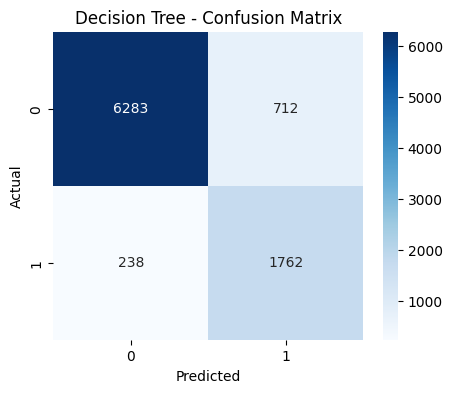

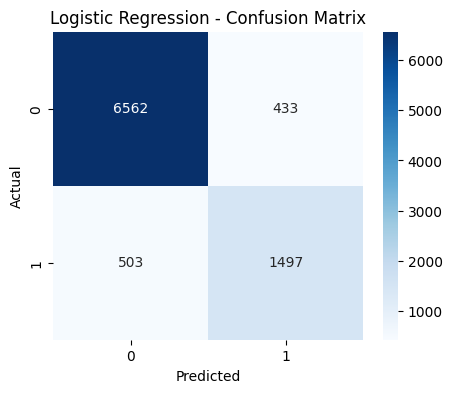

In [145]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

for name, model in models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# **Model** **Comparison**  **Graph**

In [146]:
results = {
    'Model': [
        'Decision Tree',
        'Logistic Regression'
    ],
    'Train Accuracy': [
        best_tree_train_acc,
        logistic_train_acc
    ],
    'Test Accuracy': [
        best_tree_test_acc,
        logistic_test_acc
    ]
}

results_df = pd.DataFrame(results)

print(results_df)

                 Model  Train Accuracy  Test Accuracy
0        Decision Tree        0.905993       0.894386
1  Logistic Regression        0.896542       0.895942


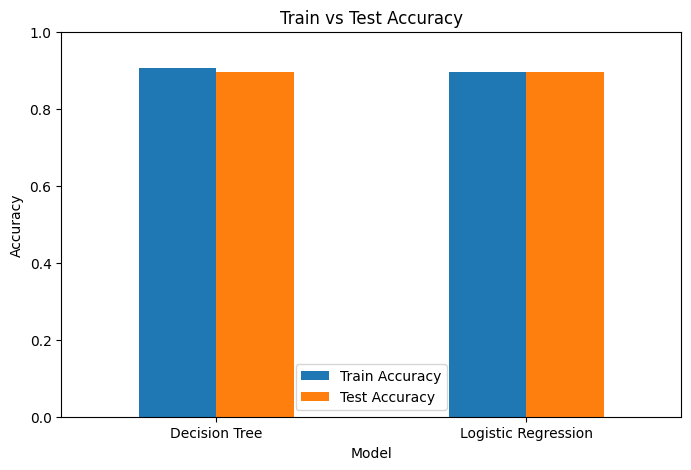

In [147]:
results_df.set_index('Model').plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Train vs Test Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [148]:
import sklearn, sys, joblib
metadata = {
    "python_version": sys.version,
    "sklearn_version": sklearn.__version__,
    "pandas_version": pd.__version__,
    "numpy_version": np.__version__,
    "joblib_version": joblib.__version__,
}
print(metadata)

{'python_version': '3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]', 'sklearn_version': '1.6.1', 'pandas_version': '2.2.3', 'numpy_version': '2.1.3', 'joblib_version': '1.6.0'}


In [149]:
requirements_content = """scikit-learn==1.6.1
pandas==2.2.3
joblib==1.6.0
numpy==2.1.3
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements_content)

print("requirements.txt has been created.")

requirements.txt has been created.


In [150]:
import joblib
from sklearn.pipeline import Pipeline

pipeline = grid_search.best_estimator_

joblib.dump(pipeline, 'loan_model.joblib')

['loan_model.joblib']